In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

%matplotlib inline

In [2]:
engine = create_engine('postgresql+psycopg2://localhost/creditsense')

df = pd.read_sql('SELECT * FROM credit_data', engine)

print("Shape:", df.shape)
print("\nFirst look:")
df.head()

Shape: (1000, 22)

First look:


,id,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,1,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,2,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,3,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,4,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,5,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,...,no known property,53,none,for free,2,skilled,2,none,yes,bad


In [3]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
id                        0
checking_status           0
duration                  0
credit_history            0
purpose                   0
credit_amount             0
savings_status            0
employment                0
installment_commitment    0
personal_status           0
other_parties             0
residence_since           0
property_magnitude        0
age                       0
other_payment_plans       0
housing                   0
existing_credits          0
job                       0
num_dependents            0
own_telephone             0
foreign_worker            0
class                     0
dtype: int64


class
good    700
bad     300
Name: count, dtype: int64


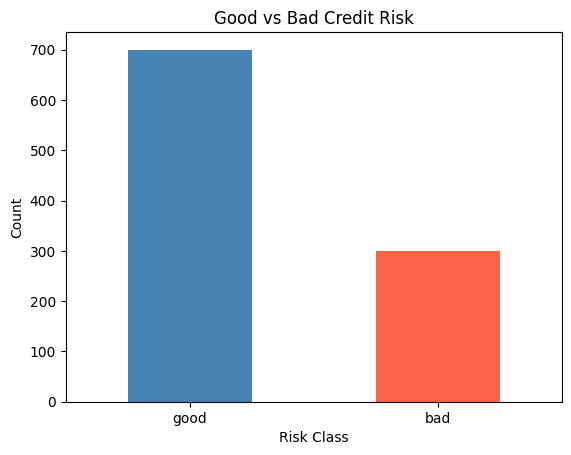

In [4]:
print(df['class'].value_counts())

df['class'].value_counts().plot(kind='bar', color=['steelblue','tomato'])
plt.title('Good vs Bad Credit Risk')
plt.xlabel('Risk Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [5]:
feat = df.copy()

# ── Feature 1 ───────────────────────────────────────────────────
feat['monthly_burden'] = feat['credit_amount'] / feat['duration']

# ── Feature 2 ───────────────────────────────────────────────────
feat['is_overdrawn'] = (feat['checking_status'] == '<0').astype(int)

# ── Feature 3 ───────────────────────────────────────────────────
feat['no_checking'] = (feat['checking_status'] == 'no checking').astype(int)

# ── Feature 4 ───────────────────────────────────────────────────
threshold = feat['credit_amount'].quantile(0.75)
feat['is_large_loan'] = (feat['credit_amount'] > threshold).astype(int)

# ── Feature 5 ───────────────────────────────────────────────────
feat['is_long_duration'] = (feat['duration'] > 24).astype(int)

# ── Feature 6 ───────────────────────────────────────────────────
feat['is_young_borrower'] = (feat['age'] < 25).astype(int)

# ── Feature 7 ───────────────────────────────────────────────────
savings_map = {
    'no known savings': 4,
    '<100': 3,
    '100<=X<500': 2,
    '500<=X<1000': 1,
    '>=1000': 0
}
feat['savings_risk_score'] = feat['savings_status'].map(savings_map).fillna(2)

# ── Feature 8 ───────────────────────────────────────────────────
employment_map = {
    'unemployed': 0,
    '<1': 1,
    '1<=X<4': 2,
    '4<=X<7': 3,
    '>=7': 4
}
feat['employment_score'] = feat['employment'].map(employment_map).fillna(1)

# ── Feature 9 ───────────────────────────────────────────────────
feat['debt_burden_index'] = feat['credit_amount'] * feat['installment_commitment'] / 100

# ── Feature 10 ──────────────────────────────────────────────────
purpose_risk = {
    'vacation': 3, 'other': 3, 'retraining': 3,
    'repairs': 2, 'education': 2, 'business': 2,
    'domestic appliance': 1, 'radio/tv': 1, 'used car': 1,
    'furniture/equipment': 1, 'new car': 1, 'car': 1
}
feat['purpose_risk'] = feat['purpose'].map(purpose_risk).fillna(2)

# ── Feature 11 ──────────────────────────────────────────────────
feat['has_multiple_credits'] = (feat['existing_credits'] > 1).astype(int)

# ── Feature 12 ──────────────────────────────────────────────────
feat['has_guarantor'] = (feat['other_parties'] != 'none').astype(int)

new_features = [
    'monthly_burden', 'is_overdrawn', 'no_checking', 'is_large_loan',
    'is_long_duration', 'is_young_borrower', 'savings_risk_score',
    'employment_score', 'debt_burden_index', 'purpose_risk',
    'has_multiple_credits', 'has_guarantor'
]
print("All 12 features created:")
for f in new_features:
    print(f"   - {f}")

All 12 features created:
   - monthly_burden
   - is_overdrawn
   - no_checking
   - is_large_loan
   - is_long_duration
   - is_young_borrower
   - savings_risk_score
   - employment_score
   - debt_burden_index
   - purpose_risk
   - has_multiple_credits
   - has_guarantor


In [6]:
categorical_cols = [
    'checking_status', 'credit_history', 'purpose', 'savings_status',
    'employment', 'personal_status', 'other_parties',
    'property_magnitude', 'other_payment_plans', 'housing',
    'job', 'own_telephone', 'foreign_worker'
]

feat_encoded = pd.get_dummies(feat, columns=categorical_cols, drop_first=True)
feat_encoded.columns = (feat_encoded.columns
    .str.replace('<=', 'LE', regex=False)
    .str.replace('<', 'LT', regex=False)
    .str.replace('>=', 'GE', regex=False)
    .str.replace('>', 'GT', regex=False)
)

# Convert target: 'good' → 0, 'bad' → 1
feat_encoded['target'] = (feat_encoded['class'] == 'bad').astype(int)

print("Target distribution:")
print(feat_encoded['target'].value_counts())
print(f"\nTotal features available: {feat_encoded.shape[1]}")

Target distribution:
target
0    700
1    300
Name: count, dtype: int64

Total features available: 63


In [7]:
from sklearn.model_selection import train_test_split

drop_cols = ['id', 'class', 'target']
X = feat_encoded.drop(columns=drop_cols)
X.columns = X.columns.str.replace(r'[\[\]<]', '', regex=True)
y = feat_encoded['target']

# 80% of data for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set:     {X_test.shape[0]} rows")
print(f"Features:     {X_train.shape[1]} columns")

Training set: 800 rows
Test set:     200 rows
Features:     60 columns


In [8]:
# Train a baseline Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Evaluate on the test set
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

auc  = roc_auc_score(y_test, y_prob)
acc  = accuracy_score(y_test, y_pred)

print(f"ROC-AUC:  {auc:.3f}")
print(f"Accuracy: {acc:.3f}")
print("\nDetailed report:")
print(classification_report(y_test, y_pred, target_names=['good','bad']))

ROC-AUC:  0.788
Accuracy: 0.780

Detailed report:
              precision    recall  f1-score   support

        good       0.80      0.91      0.85       140
         bad       0.70      0.47      0.56        60

    accuracy                           0.78       200
   macro avg       0.75      0.69      0.71       200
weighted avg       0.77      0.78      0.77       200



In [9]:
# Hyperparameter tuning with GridSearchCV
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],        # number of trees
    'max_depth': [None, 10, 20],       # each tree depth
    'min_samples_split': [2, 5],       # needed to split a node
    'class_weight': ['balanced', None] # handles imbalance
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,  
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best cross-val AUC: {grid_search.best_score_:.3f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits


/Users/dikshaganchaudhuri/Desktop/creditsense/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/dikshaganchaudhuri/Desktop/creditsense/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/dikshaganchaudhuri/Desktop/creditsense/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warn

Best parameters: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best cross-val AUC: 0.796


In [10]:
# Evaluate the tuned model
best_rf = grid_search.best_estimator_

y_pred_tuned = best_rf.predict(X_test)
y_prob_tuned = best_rf.predict_proba(X_test)[:, 1]

auc_tuned = roc_auc_score(y_test, y_prob_tuned)
acc_tuned  = accuracy_score(y_test, y_pred_tuned)

print(f"Tuned ROC-AUC:  {auc_tuned:.3f}  (target: 0.87)")
print(f"Tuned Accuracy: {acc_tuned:.3f}  (target: 0.82)")
print("\nDetailed report:")
print(classification_report(y_test, y_pred_tuned, target_names=['good','bad']))

Tuned ROC-AUC:  0.804  (target: 0.87)
Tuned Accuracy: 0.785  (target: 0.82)

Detailed report:
              precision    recall  f1-score   support

        good       0.83      0.86      0.85       140
         bad       0.65      0.60      0.63        60

    accuracy                           0.79       200
   macro avg       0.74      0.73      0.74       200
weighted avg       0.78      0.79      0.78       200



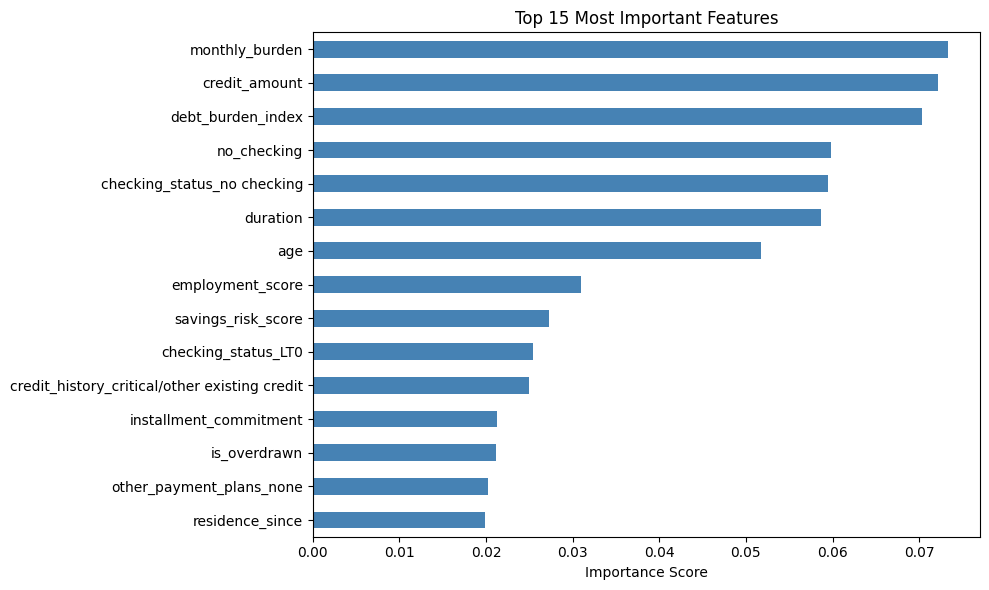

In [11]:
# Feature importance chart
importances = pd.Series(best_rf.feature_importances_, index=X.columns)
top15 = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
top15.plot(kind='barh', color='steelblue')
plt.title('Top 15 Most Important Features')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [12]:
# XGBoost model
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

neg = sum(y_train == 0)
pos = sum(y_train == 1)
scale = neg / pos
print(f"Class ratio (good/bad): {scale:.2f} — passed to scale_pos_weight")

param_grid_xgb = {
    'n_estimators':    [200, 300, 500],
    'max_depth':       [3, 4, 6],
    'learning_rate':   [0.01, 0.05, 0.1],
    'subsample':       [0.8, 1.0],
    'colsample_bytree':[0.8, 1.0]
}

xgb = XGBClassifier(
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='auc',
    verbosity=0
)

grid_xgb = GridSearchCV(
    xgb,
    param_grid_xgb,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train, y_train)

print("\nBest parameters:", grid_xgb.best_params_)
print(f"Best cross-val AUC: {grid_xgb.best_score_:.3f}")

Class ratio (good/bad): 2.33 — passed to scale_pos_weight
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 500, 'subsample': 0.8}
Best cross-val AUC: 0.795


In [13]:
# Evaluate on test set
best_xgb = grid_xgb.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

auc_xgb = roc_auc_score(y_test, y_prob_xgb)
acc_xgb = accuracy_score(y_test, y_pred_xgb)

print(f"XGBoost ROC-AUC:  {auc_xgb:.3f}  (target ≥ 0.87)")
print(f"XGBoost Accuracy: {acc_xgb:.3f}  (target ≥ 0.82)")
print("\nDetailed report:")
print(classification_report(y_test, y_pred_xgb, target_names=['good','bad']))

XGBoost ROC-AUC:  0.802  (target ≥ 0.87)
XGBoost Accuracy: 0.735  (target ≥ 0.82)

Detailed report:
              precision    recall  f1-score   support

        good       0.85      0.75      0.80       140
         bad       0.55      0.70      0.61        60

    accuracy                           0.73       200
   macro avg       0.70      0.72      0.71       200
weighted avg       0.76      0.73      0.74       200



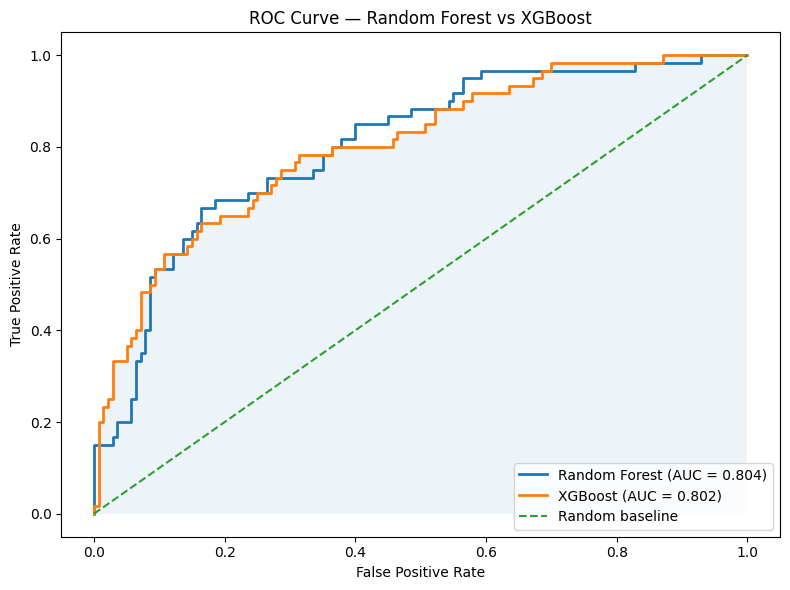

ROC curve saved:
   /Users/dikshaganchaudhuri/Desktop/creditsense/data/roc_curve_comparison.png


In [14]:
# Compare Random Forest vs XGBoost on the same ROC curve
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

project_root = os.path.dirname(os.getcwd())

data_dir = os.path.join(project_root, 'data')

os.makedirs(data_dir, exist_ok=True)

y_prob_rf  = best_rf.predict_proba(X_test)[:, 1]
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

fpr_rf,  tpr_rf,  _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf,  tpr_rf,  lw=2,
         label=f'Random Forest (AUC = {auc_tuned:.3f})')
plt.plot(fpr_xgb, tpr_xgb, lw=2,
         label=f'XGBoost (AUC = {auc_xgb:.3f})')

plt.plot([0,1], [0,1], linestyle='--', label='Random baseline')
plt.fill_between(fpr_xgb, tpr_xgb, alpha=0.08)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Random Forest vs XGBoost')
plt.legend(loc='lower right')

plt.tight_layout()

save_path = os.path.join(data_dir, 'roc_curve_comparison.png')
plt.savefig(save_path, dpi=150)

plt.show()

print("ROC curve saved:")
print(f"   {save_path}")

In [16]:
# Overwrite saved model with XGBoost (production-ready)
import joblib
import subprocess

project_root = os.path.dirname(os.getcwd())

models_dir = os.path.join(project_root, 'src', 'models')

os.makedirs(models_dir, exist_ok=True)

model_path = os.path.join(models_dir, 'credit_risk_model.pkl')
joblib.dump(best_xgb, model_path)

print("Saved updated model:")
print(f"   {model_path}")

requirements_path = os.path.join(project_root, 'requirements.txt')

result = subprocess.run(
    ['pip', 'freeze'],
    capture_output=True,
    text=True
)

with open(requirements_path, 'w') as f:
    f.write(result.stdout)

print("Updated requirements file:")
print(f"   {requirements_path}")

Saved updated model:
   /Users/dikshaganchaudhuri/Desktop/creditsense/src/models/credit_risk_model.pkl
Updated requirements file:
   /Users/dikshaganchaudhuri/Desktop/creditsense/requirements.txt
